In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
orders = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")
customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")

In [3]:
# Chuyển đổi thời gian
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])



In [4]:
print("\n1. QUAN HỆ GIỮA CÁC BẢNG DỮ LIỆU")
# Kiểm tra các khóa chính và khóa ngoại
print(f"Orders: {len(orders):,} đơn hàng")
print(f"Customers: {len(customers):,} khách hàng")
print(f"Order_items: {len(order_items):,} items")
print(f"Reviews: {len(reviews):,} reviews")
print(f"Payments: {len(payments):,} payments")


1. QUAN HỆ GIỮA CÁC BẢNG DỮ LIỆU
Orders: 99,441 đơn hàng
Customers: 99,441 khách hàng
Order_items: 112,650 items
Reviews: 99,224 reviews
Payments: 103,886 payments


In [5]:
# Join các bảng
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items.groupby('order_id')['price'].sum().reset_index(), on='order_id', how='left')
df = df.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
df = df.merge(reviews.groupby('order_id')['review_score'].mean().reset_index(), on='order_id', how='left')

print(f"\nSau khi merge: {len(df):,} orders với đầy đủ thông tin")


Sau khi merge: 99,441 orders với đầy đủ thông tin


In [ ]:
print("\n2. PHÂN TÍCH LẦN MUA ĐẦU TIÊN")
# Lọc các đơn hàng hợp lệ (đã giao hoặc đã ship, tránh đơn bị hủy)
valid_orders = orders[orders['order_status'].isin(['delivered', 'shipped'])].copy()
# JOIN để lấy customer_unique_id cho mỗi đơn hàng
order_customer = pd.merge(
    valid_orders[['order_id', 'customer_id', 'order_purchase_timestamp']], 
    customers[['customer_id', 'customer_unique_id']], 
    on='customer_id', 
    how='inner'
)

# Tìm ngày mua đầu tiên của từng khách hàng duy nhất
first_purchase = order_customer.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_time']

# Tích hợp lại vào bảng order_customer để biết đơn hàng nào là đơn hàng đầu tiên
order_customer = pd.merge(order_customer, first_purchase, on='customer_unique_id', how='left')
order_customer['num_orders'] = order_customer['order_purchase_timestamp'] == order_customer['first_purchase_time']

# Lọc ra danh sách các order_id là đơn đầu tiên
first_orders_only = (order_customer['num_orders'] == True).sum()

print(f"\nKhách hàng chỉ mua 1 lần: {first_orders_only:,} ({first_orders_only/len(order_customer)*100:.1f}%)")


2. PHÂN TÍCH LẦN MUA ĐẦU TIÊN

Khách hàng chỉ mua 1 lần: 94,667 (97.0%)

Khách hàng chỉ mua 1 lần: 94,667 (97.0%)


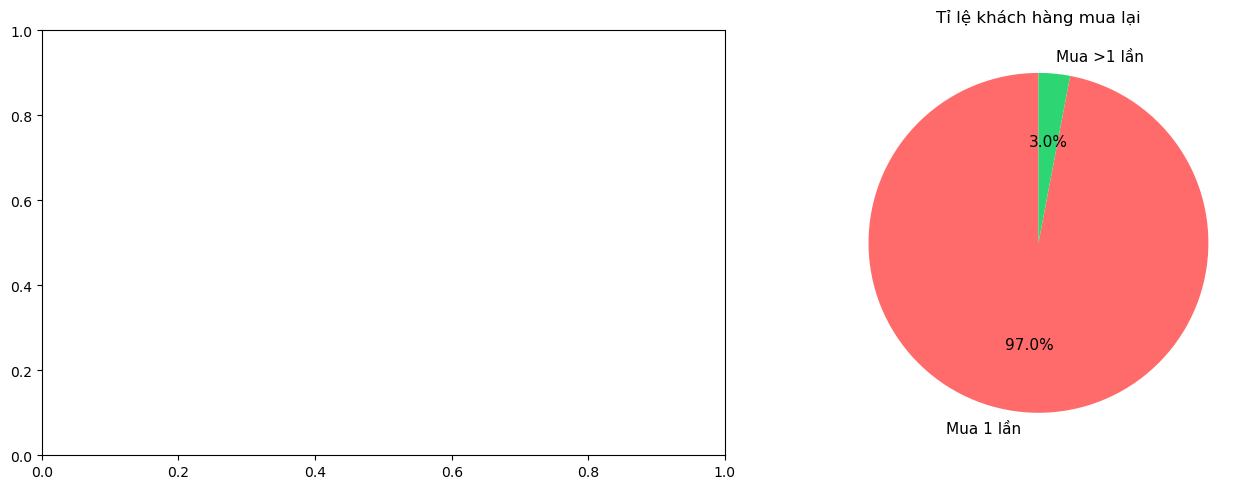

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart số lần mua
(
    order_customer
    .value_counts()
    .sort_index()
    .head(20)
    .plot(
        kind='bar',
        ax=axes[0],
        color='steelblue'
    )
)

axes[0].set_title('Phân phối số lần mua')
axes[0].set_xlabel('Số lần mua')
axes[0].set_ylabel('Số khách hàng')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
labels = ['Mua 1 lần', 'Mua >1 lần']
sizes = [first_orders_only.shape[0], len(order_customer) - first_orders_only.shape[0]]

axes[1].pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff6b6b', '#2ed573'],
    textprops={'fontsize': 11}
)

axes[1].set_title('Tỉ lệ khách hàng mua lại')

plt.tight_layout()
plt.show()

#### Nhật xét 
##### Ta thấy cái chỉ số của bộ data này chỉ Con số 97.0% khách hàng chỉ mua 1 lần (chỉ có 3.0% quay lại mua lần thứ 2) rất khó tìm hiểu churn trong này